# NB-05: T-4 上り3Fタイム予測（秒）

**ターゲット**: 各馬の上り3F（最終 3ハロンのラップ秒）を回帰予測する。  
**モデル**: LightGBM Regression  
**主評価指標**: MAE (秒), RMSE, Spearman 相関

### 重要性
上り3Fタイム予測は T-9（走破タイム）への入力となり、最終的に T-1（勝率）の入力にも使われる。
馬の末脚能力を数値化する重要な中間モデル。


In [1]:
import sys
sys.path.insert(0, "/home/jovyan/work/keiba-vpn")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from src.pipeline.models.notebook_utils import (
    load_master, encode_cats, feature_set,
    train_lgb, oof_predict, eval_regression, save_oof,
    DEFAULT_PARAMS_REGRESSION, SURFACE_CATS,
)
print("imports OK")


imports OK


## 1. データ読み込み

In [2]:
df = load_master()

# last_3f はマスターデータセットに含まれている
print(f"last_3f coverage: {df['last_3f'].notna().mean():.1%}")
print(f"last_3f range: {df['last_3f'].min():.1f} ~ {df['last_3f'].max():.1f} 秒")
print(f"last_3f mean: {df['last_3f'].mean():.2f} 秒")

# 外れ値除去 (30秒未満・50秒超は障害除いても異常)
df_clean = df[df["last_3f"].between(28, 50)].copy()
print(f"\nフィルタ後: {len(df_clean):,} / {len(df):,}")
df["surface_cat"] = df["surface_cat"].astype(str)  # Categorical → str


last_3f coverage: 100.0%
last_3f range: -71.0 ~ 120.0 秒
last_3f mean: 40.45 秒



フィルタ後: 238,347 / 286,060


## 2. 特徴量定義

In [3]:
# T-4: 馬の末脚能力 + コース特性を重視
FEAT_T4 = feature_set(df_clean, extra=[
    # 過去の上り3F実績
    "speed_max", "speed_avg", "speed_distance",
    "speed_recent_1", "speed_recent_2", "speed_recent_3",
])
print(f"特徴量数: {len(FEAT_T4)}")

CAT_USE = [c for c in ["venue","surface","direction","grade","track_condition","weather","sex"] if c in df_clean.columns]
df_clean = encode_cats(df_clean, CAT_USE)


特徴量数: 60


## 3. 馬場別モデル学習

In [4]:
from src.pipeline.models.notebook_utils import DEFAULT_PARAMS_REGRESSION

params_t4 = {**DEFAULT_PARAMS_REGRESSION}
models_t4: dict = {}
oof_all_t4 = pd.DataFrame()

for sc in SURFACE_CATS:
    df_sc = df_clean[df_clean["surface_cat"] == sc].copy()
    df_tr = df_sc[df_sc["split"] == "train"]
    df_vl = df_sc[df_sc["split"] == "valid"]
    print(f"\n=== {sc} ===  train={len(df_tr):,}  valid={len(df_vl):,}")
    if len(df_tr) < 100:
        print("  スキップ"); continue

    model = train_lgb(df_tr, df_vl, FEAT_T4, "last_3f", params_t4, cat_features=CAT_USE)
    models_t4[sc] = model

    pred_vl = model.predict(df_vl[FEAT_T4])
    metrics = eval_regression(df_vl["last_3f"].values, pred_vl)
    sc_r, _ = spearmanr(df_vl["last_3f"].dropna(), pred_vl[:df_vl["last_3f"].notna().sum()])
    print(f"  Valid: MAE={metrics['mae']:.3f}s  RMSE={metrics['rmse']:.3f}s  Spearman={sc_r:.4f}")

    # OOF
    oof = oof_predict(df_tr, FEAT_T4, "last_3f", params_t4, cat_features=CAT_USE)
    oof_df = df_tr[["race_id","horse_number","surface_cat","last_3f","split"]].copy()
    oof_df["t4_oof"] = oof.values
    oof_all_t4 = pd.concat([oof_all_t4, oof_df], ignore_index=True)

print("\nモデル学習完了:", list(models_t4.keys()))



=== turf ===  train=90,032  valid=18,779


[100]	train's l1: 0.798145	train's l2: 1.20714	valid's l1: 0.81971	valid's l2: 1.25815


[200]	train's l1: 0.762918	train's l2: 1.09816	valid's l1: 0.811063	valid's l2: 1.24244


  Valid: MAE=0.810s  RMSE=1.114s  Spearman=0.6853



=== dirt ===  train=95,797  valid=19,983


[100]	train's l1: 0.940455	train's l2: 1.62416	valid's l1: 0.998254	valid's l2: 1.81366


  Valid: MAE=0.998s  RMSE=1.346s  Spearman=0.7023



=== hurdle ===  train=0  valid=0
  スキップ

モデル学習完了: ['turf', 'dirt']


## 4. テスト評価 & OOF 保存

[turf] Test: {'mae': 0.8723705786594362, 'rmse': 1.2682587713879945, 'corr': 0.5798541906670226}


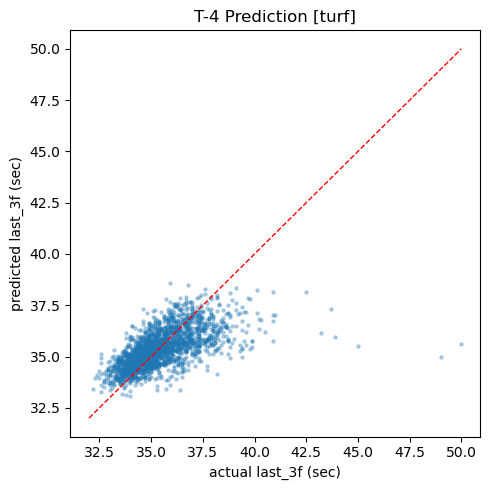

[dirt] Test: {'mae': 0.9971432930946044, 'rmse': 1.3475972002963428, 'corr': 0.6858960817715043}


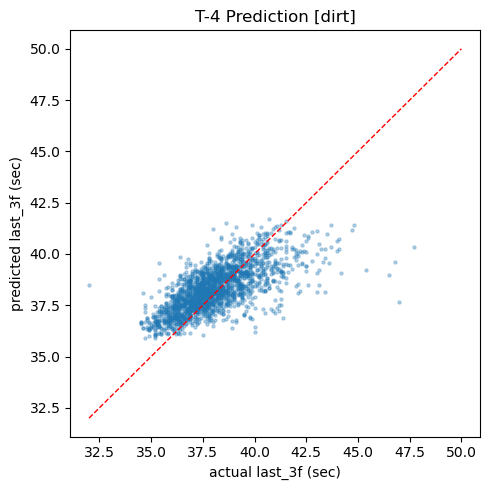

T-4 OOF saved: shape=(185829, 6)


In [5]:
for sc, model in models_t4.items():
    df_te = df_clean[(df_clean["surface_cat"] == sc) & (df_clean["split"] == "test")]
    if df_te.empty: continue
    pred_te = model.predict(df_te[FEAT_T4])
    metrics = eval_regression(df_te["last_3f"].values, pred_te)
    print(f"[{sc}] Test: {metrics}")

    # 予測vs実測 散布図
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(df_te["last_3f"].values[:2000], pred_te[:2000], alpha=0.3, s=5)
    ax.set_xlabel("actual last_3f (sec)")
    ax.set_ylabel("predicted last_3f (sec)")
    ax.set_title(f"T-4 Prediction [{sc}]")
    mn = min(df_te["last_3f"].min(), pred_te.min())
    mx = max(df_te["last_3f"].max(), pred_te.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=1)
    plt.tight_layout(); plt.show()

if not oof_all_t4.empty:
    oof_all_t4.to_parquet("/home/jovyan/work/keiba-vpn/data/local/modeling/oof/t4_oof.parquet", index=False)
    print(f"T-4 OOF saved: shape={oof_all_t4.shape}")


## 5. 特徴量重要度

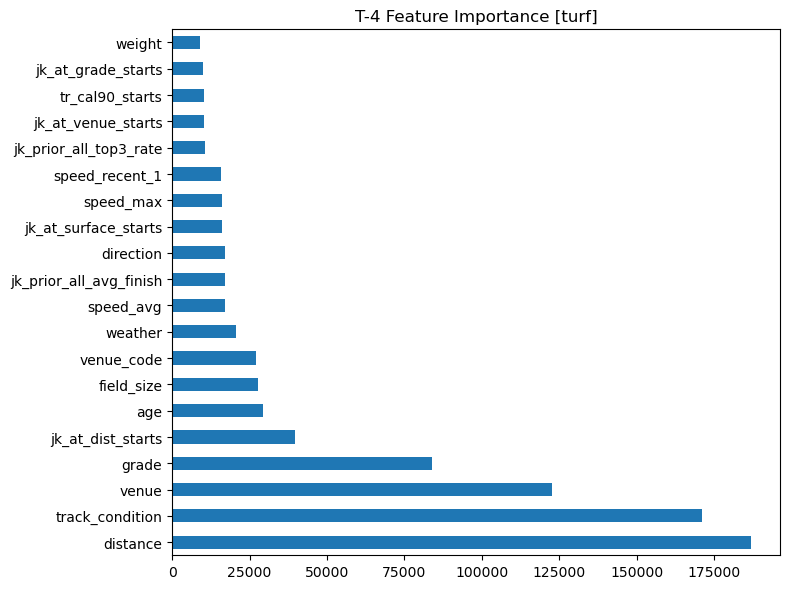

Top 10: {'distance': 186928.16690540314, 'track_condition': 171025.71602010727, 'venue': 122618.9138250351, 'grade': 83754.26187467575, 'jk_at_dist_starts': 39627.255410671234, 'age': 29337.305161952972, 'field_size': 27819.81373357773, 'venue_code': 27182.601649284363, 'weather': 20591.831334590912, 'speed_avg': 17170.910356998444}


In [6]:
best_sc = max(models_t4, key=lambda s: models_t4[s].num_trees()) if models_t4 else None
if best_sc:
    imp = pd.Series(models_t4[best_sc].feature_importance(importance_type="gain"), index=FEAT_T4)
    imp.sort_values(ascending=False).head(20).plot.barh(figsize=(8,6),
        title=f"T-4 Feature Importance [{best_sc}]")
    plt.tight_layout(); plt.show()
    print("Top 10:", imp.sort_values(ascending=False).head(10).to_dict())
